<a href="https://colab.research.google.com/github/IKYTARO/DeepLearningSchool/blob/main/Semester_1_ML_CV/week_01_ml_intro/hw_1_game_of_thrones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

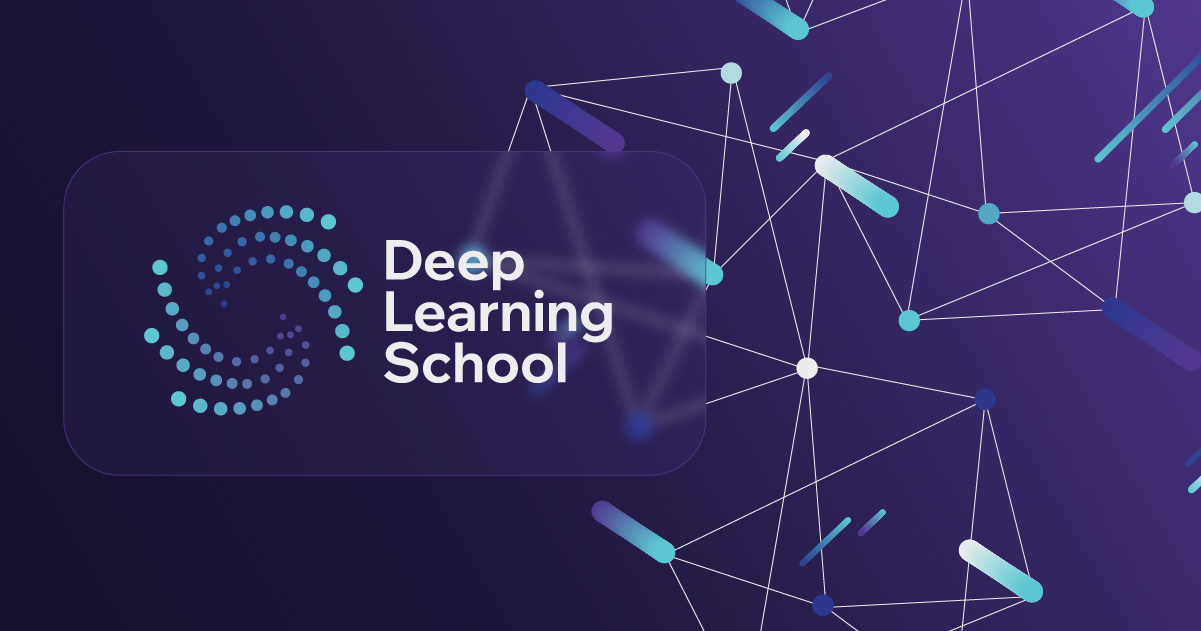

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

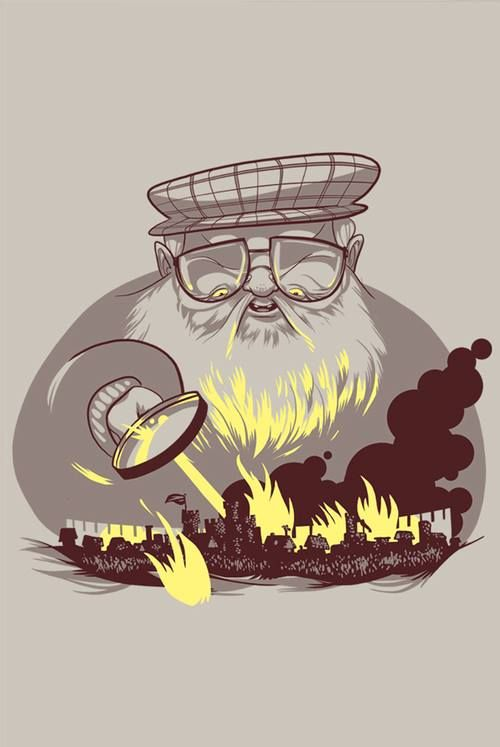

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [280]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 35.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 33.6MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

* Зададим цветовую палитру для более наглядного и красивого представления данных.

In [282]:
color_palette = ['#AD4A2B', '#6A7B73', '#3D3E3B', '#E78F63', '#F7C7B1']
colors = ['#6A7B73', '#E78F63']

cmap = LinearSegmentedColormap.from_list("color_palette", colors, N=50)

sns.set(style="whitegrid", palette=color_palette)

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [283]:
data = pd.read_csv("/content/game_of_thrones_train.csv", index_col='S.No')
test = pd.read_csv("/content/game_of_thrones_test.csv", index_col='S.No')

* Посмотрим на случайную выборку данных и убедимся, что все корректно загрузилось

In [284]:
data.sample(5)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,,,,,
383,Briar,NaN,0,Free Folk,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.010033,1
612,Hugh Beesbury,Ser,0,NaN,NaN,NaN,NaN,NaN,House Beesbury,NaN,0,0,0,1,0,NaN,NaN,NaN,NaN,0,1,NaN,0,0.013378,1
877,Aemon Estermont,Ser,1,Stormlands,NaN,NaN,NaN,NaN,House Estermont,NaN,0,1,1,1,1,NaN,NaN,NaN,NaN,0,1,NaN,0,0.030100,1
1077,Hairy Hal,NaN,0,NaN,NaN,NaN,NaN,NaN,Night's Watch,NaN,0,0,1,1,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.033445,0
1260,Nymella Toland,Ghost Hill,0,Dornish,NaN,NaN,NaN,NaN,House Toland,NaN,0,0,1,1,1,NaN,NaN,NaN,NaN,0,1,NaN,0,0.043478,1


* Сразу выведем размер датасета для понимания общего количества признаков и объектов

In [285]:
data.shape

(1557, 25)

Посмотрите, какие типы данных представлены в нашем датасете

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [286]:
data.describe(include='object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [287]:
data.describe(include = [np.number]).T[['count', 'min', 'max']].style.background_gradient(cmap=cmap)

,count,min,max
male,1557.000000,0.000000,1.000000
dateOfBirth,279.000000,-25.000000,299.000000
book1,1557.000000,0.000000,1.000000
book2,1557.000000,0.000000,1.000000
book3,1557.000000,0.000000,1.000000
book4,1557.000000,0.000000,1.000000
book5,1557.000000,0.000000,1.000000
isAliveMother,18.000000,0.000000,1.000000
isAliveFather,22.000000,0.000000,1.000000
isAliveHeir,21.000000,0.000000,1.000000


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [288]:
missing_values = pd.DataFrame({
    'feature': data.columns,
    'NaN_count': data.isna().sum().values,
    'NaN_percentage': ((data.isna().sum() / len(data) * 100).round(2)).values
})
missing_values.sort_values('NaN_count', ascending=False)
missing_values.style.background_gradient(cmap=cmap)

,feature,NaN_count,NaN_percentage
0,name,0,0.000000
1,title,840,53.950000
2,male,0,0.000000
3,culture,1069,68.660000
4,dateOfBirth,1278,82.080000
5,mother,1539,98.840000
6,father,1535,98.590000
7,heir,1536,98.650000
8,house,381,24.470000
9,spouse,1357,87.150000


В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

* Построим гистограмму распределния признака `popularity` и дополнительно вычислим некоторые храктеристики распределения, чтобы иметь более полную картину.

> **Коэффициент асимметрии** (*skewness*) - величина, характеризующая асимметрию распределения.

$$
A_S = \frac{\mu_3}{\sigma^3},\text{ где}
$$
- $\mu_3 = E[(X - E[X])^3]$ - третий центральный момент,
- $\sigma = \sqrt{D[X]}$ - стандартное отклонение.

Соотношение между средним, медианой и модой в зависимости от коэффициента асимметрии продемонстрировано на изображениии ниже.

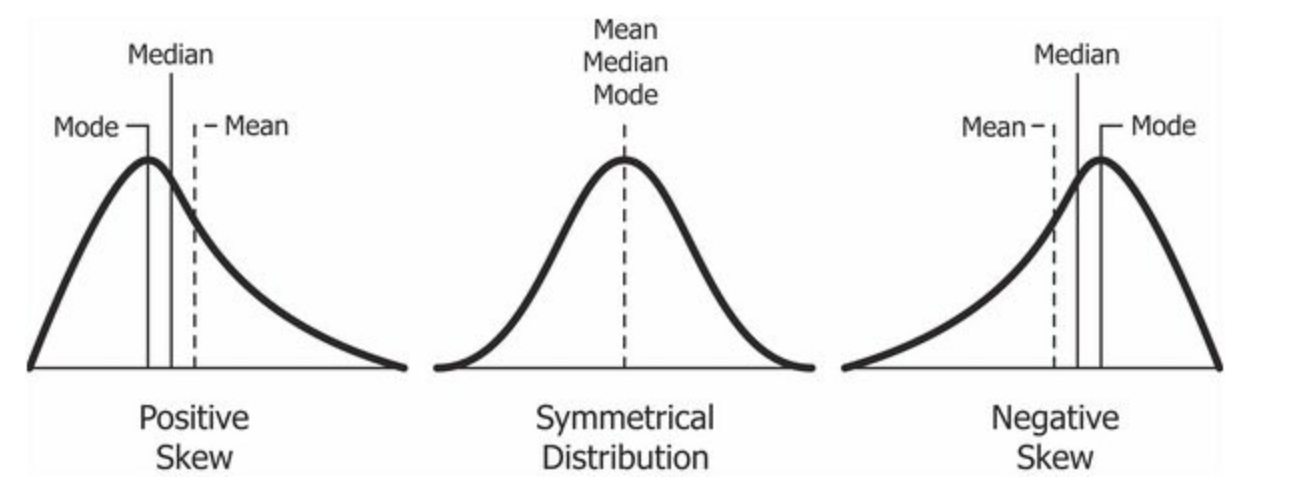

>**Коэффициент эксцесса** (*kurtosis*) - мера остроты пика распределения случайной величины. Он положителен, если пик распределения около математического ожидания острый, и отрицателен, если пик очень гладкий. Для нормального распределения данный коэффициент равен нулю.

$$
\gamma_2 = \frac{\mu_4}{\sigma^4} - 3\text{, где}
$$
- $\mu_4 = E[(X - E[X])^4]$ - четвертый центральный момент,
- $\sigma$ - стандартное отклонение,
- "минус три" в конце формулы введено для того, чтобы коэффициент эксцесса стандартного нормального распределения был равен нулю.

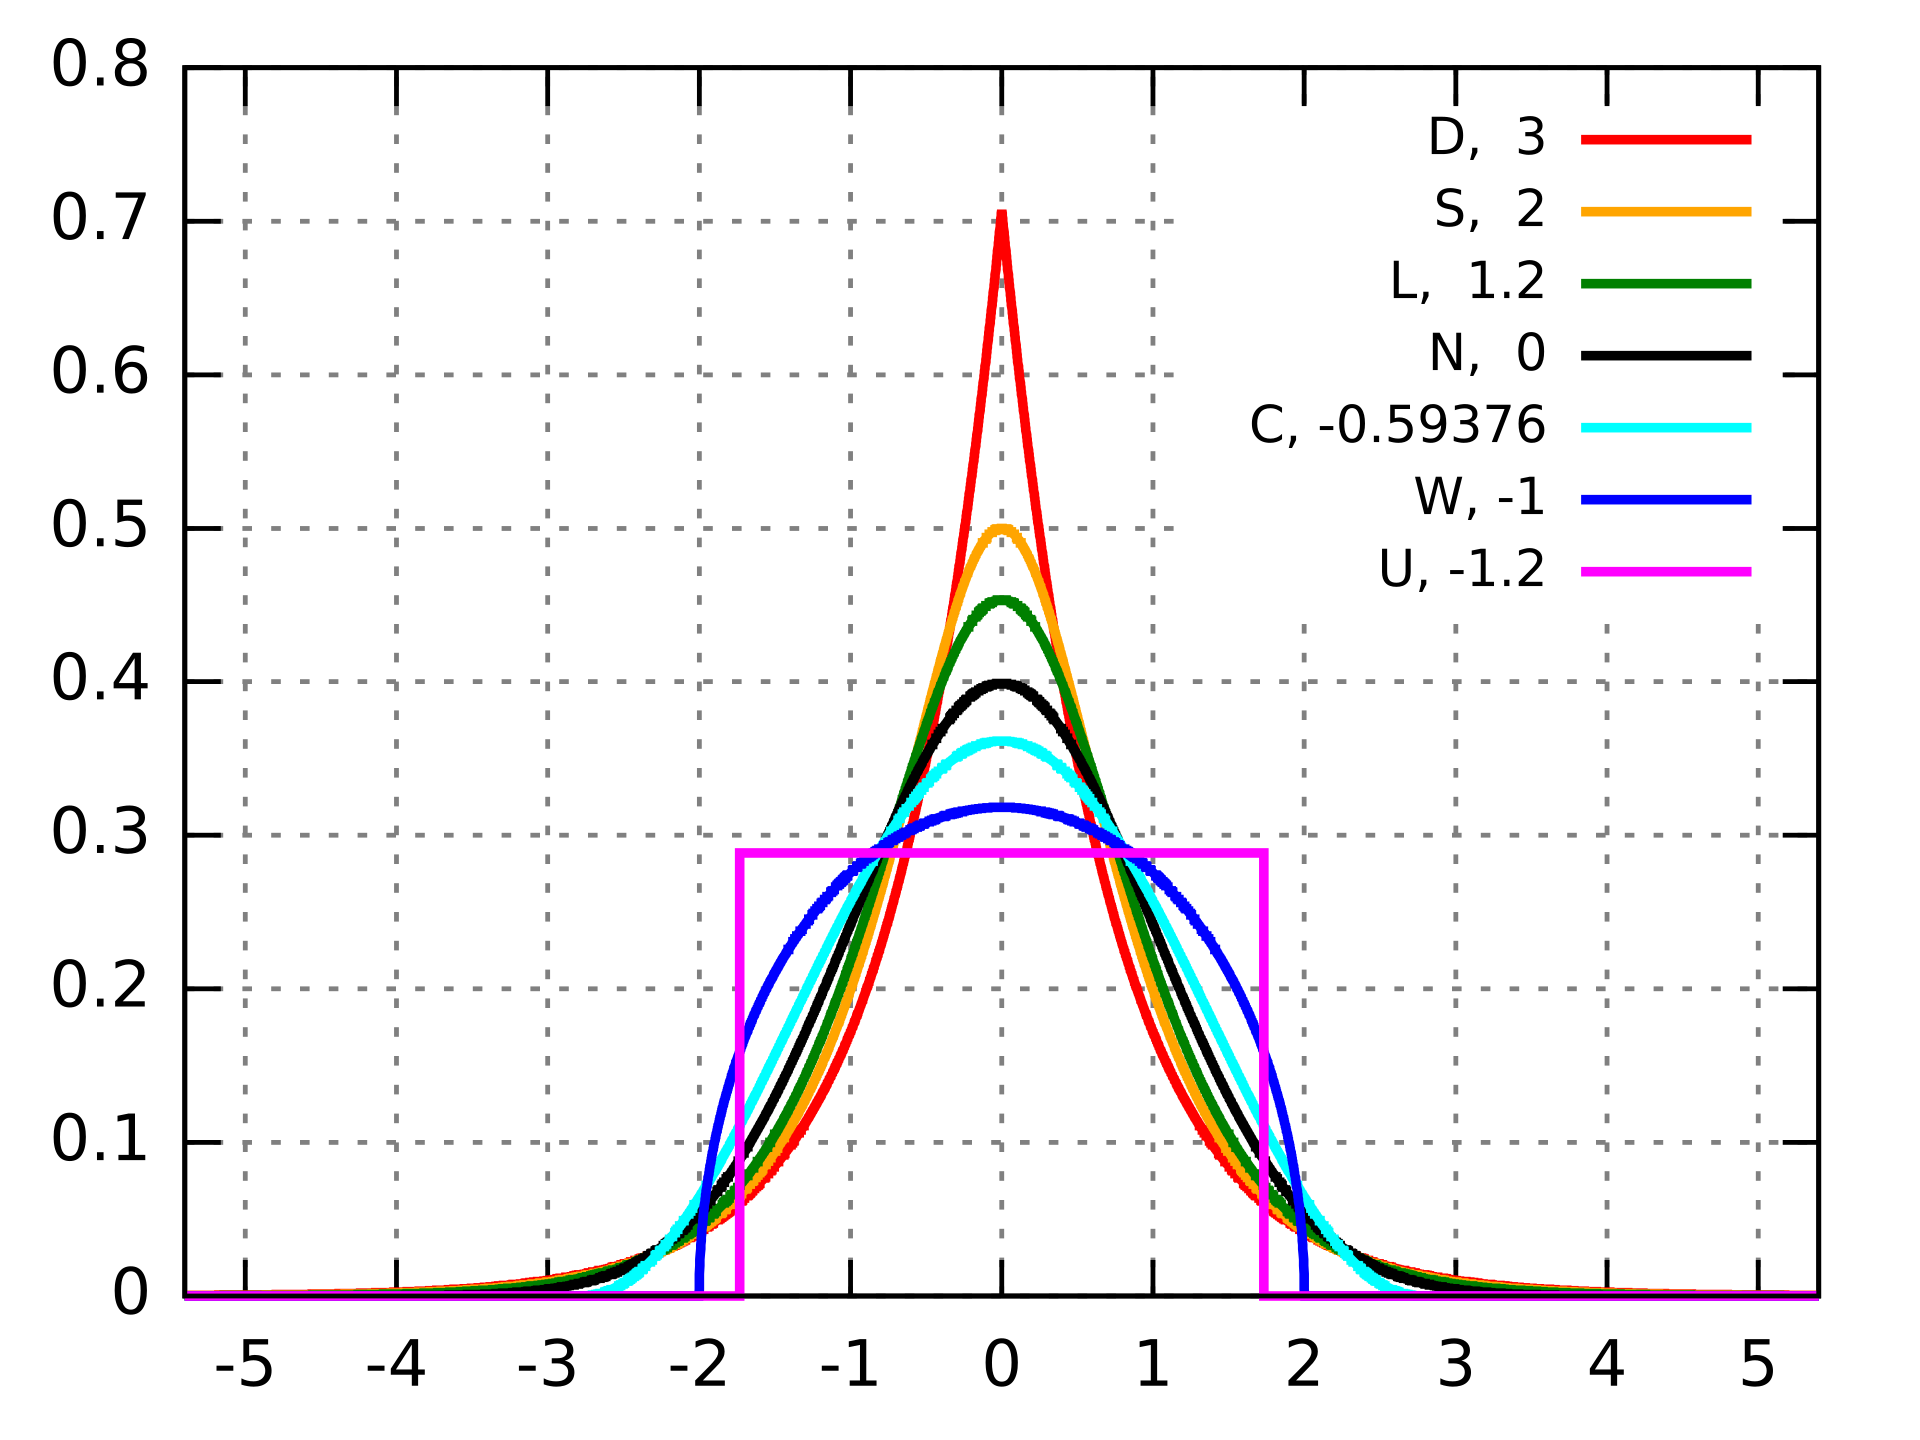

In [289]:
def plot_popularity_dist(axes, dist, title="Распределение popularity", show_labels=True):
  axes.hist(dist, bins=50)
  axes.set_title(title + f' (Skewness: {dist.skew():.2f}, Kurtosis: {dist.kurt():.2f})')

  if (show_labels):
    axes.set_xlabel("Значение признака")
    axes.set_ylabel("Частота")

  mean = np.mean(dist.values)
  median = np.quantile(dist.values,q=0.5)

  axes.axvline(x=mean, color='g', linestyle = '--', label='mean')
  axes.axvline(x=median, color='b', linestyle = '-', label='median')
  axes.legend()

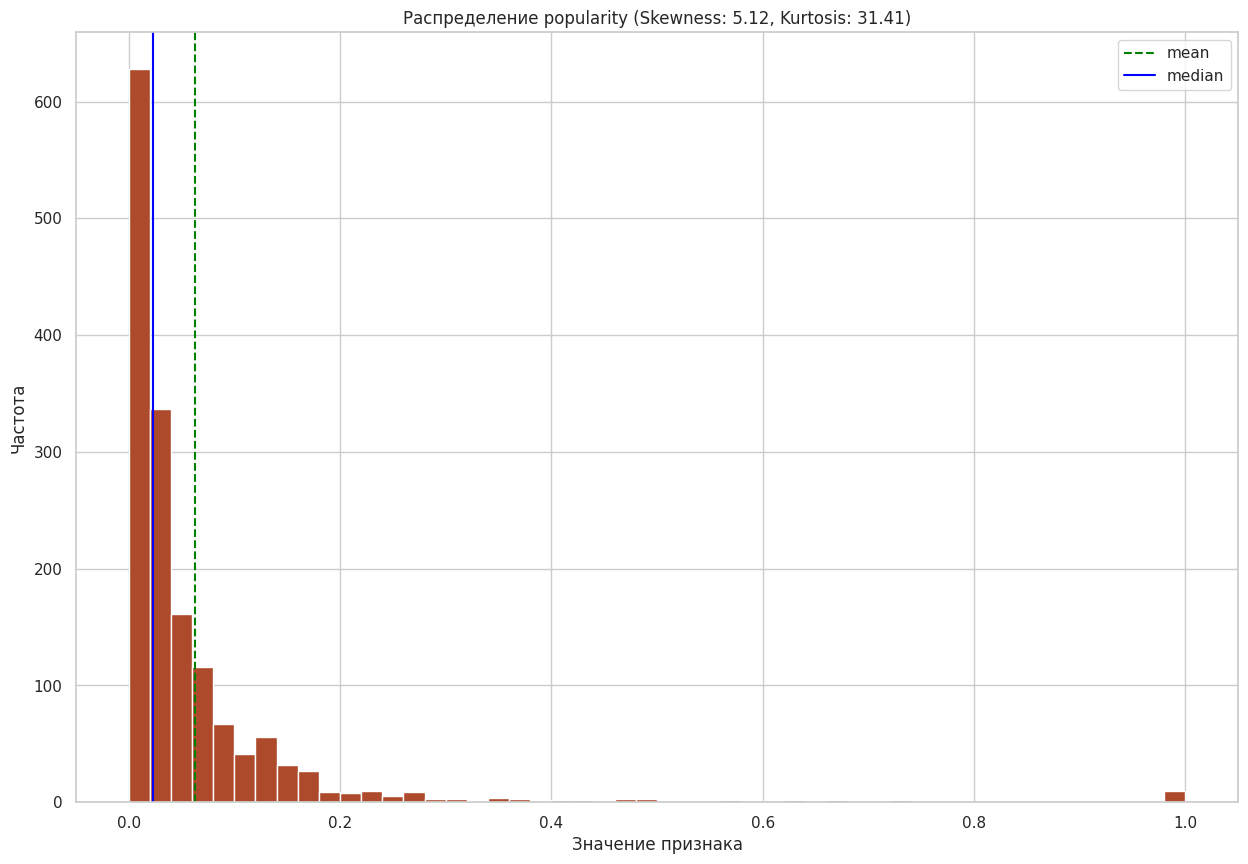

In [290]:
fig, axes = plt.subplots(figsize=(15, 10))
plot_popularity_dist(axes, data['popularity'])

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

* Будем использовать подход с преобразованием признака по логарифмической шкале. В нашем случае высокий положительный коэффициент асимметрии (5.12) и высокий положительный коэффициент эксцесса (31.41), который как раз таки отражает большое количество выбросов и "тяжелый" правый хвост распределения. Логарифмическое преобразование должно это компенсировать.

* Попробуем поэкспериментировать с различными значениями коэффициента M.

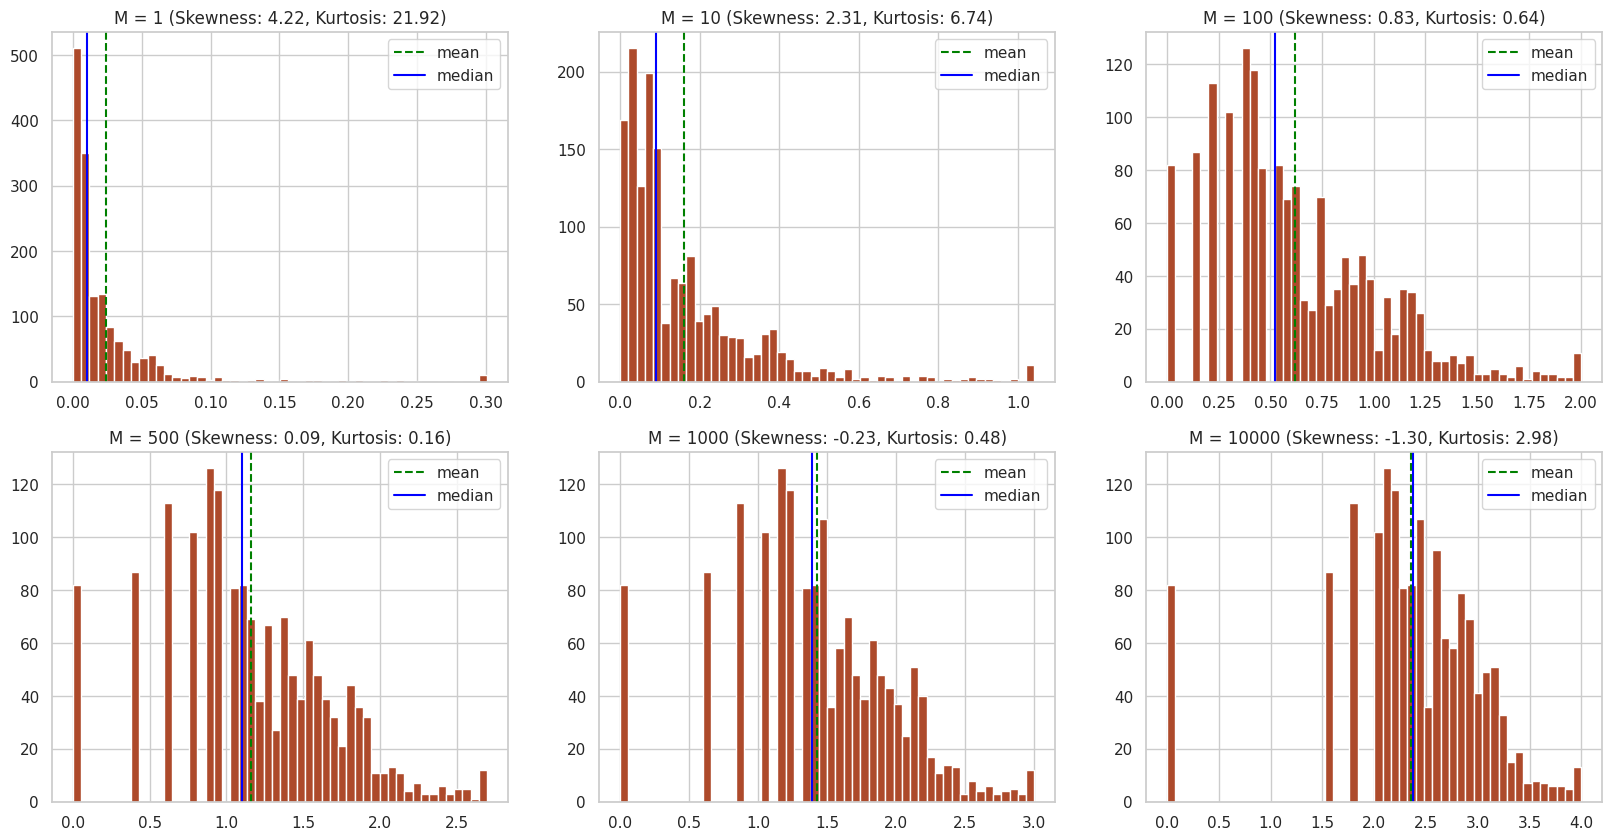

In [291]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
M_values = [1, 10, 100, 500, 1000, 10000]

for i, M in enumerate(M_values):
  row, col = i // 3, i % 3
  scaled_popularity = np.log10(data['popularity']*M + 1)
  plot_popularity_dist(axes[row, col], scaled_popularity, title=f'M = {M}', show_labels=False)

* Видим, что значение M = 500 дает характеристики распределения близкие к нормальному (skewness = 0.09 и kurtosis = 0.16). Поэтому будем использовать данное значение в качестве коэффициента преобразования. Обернем данное преобразование в функцию.

In [292]:
def scale_popularity(df, M=500):
  df['popularity'] = np.log10(df['popularity']*M + 1)

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

* Визуализируем распределение признака `numDeadRelations`. Убеждаемся, что лишь для малого числа персонажей значение признака отлично от 0.

In [293]:
data['numDeadRelations'].value_counts()

,count
numDeadRelations,
0,1488
1,24
5,10
7,7
4,7
3,4
10,4
2,4
6,3


<Axes: title={'center': 'Распределение numDeadRelations'}, xlabel='numDeadRelations', ylabel='Count'>

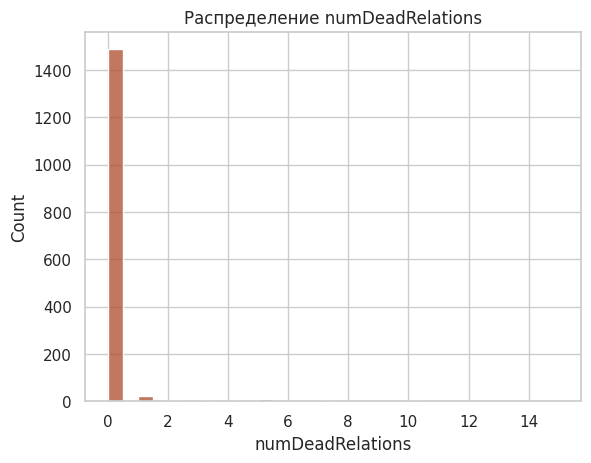

In [294]:
plt.title("Распределение numDeadRelations")
sns.histplot(data['numDeadRelations'], bins=30, stat='count')

* Обернем создание признака `boolDeadRelations` в отдельную функцию.

In [295]:
def create_boolDeadRelations(df):
  df['boolDeadRelations'] = df['numDeadRelations'] > 0

Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

* Обернем создание указанных выше признаков (`age_value` и `age_no_data`) в отдельную функцию.

In [296]:
def create_age_features(df):
  df['age_value'] = df['age'].fillna(0)
  df['age_no_data'] = [1 if np.isnan(x) else 0 for x in df['age']]
  df.drop('age', axis=1, inplace=True)

Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

* Поступим аналогичным образом и обернем создание признака `dateOfBirth_value` в отдельную функцию. Создание признака `dateOfBirth_no_data` опустим согласно замечанию выше, чтобы избежать возникновения идентичных столбцов.



In [297]:
def create_dateOfBirth_value(df):
  df['dateOfBirth_value'] = df['dateOfBirth'].fillna(0)
  df.drop('dateOfBirth', axis=1, inplace=True)

* Объединим все предыдцщие этапы по обработке и созданию признаков в одну функцию.

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [298]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [299]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [300]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [301]:
# По аналогии с примером выше инвертируйте словарь cultures_grouped

cultures_grouped_inverted = {}
for key in cultures_grouped.keys():
  for value in cultures_grouped[key]:
    cultures_grouped_inverted.update({value:key})

cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

* Аналогично предыдущим шагам выделим данное преобразование в отдельную функцию.

In [302]:
def create_culture_groups(df, groups=cultures_grouped_inverted):
  df['culture_grouped'] = df['culture'].str.lower().map(groups)
  df['culture_grouped'] = df['culture_grouped'].fillna('culture_no_data')
  df.drop('culture', axis=1, inplace=True)

* Проверим результат работы функци на копии исходного датасета.

In [303]:
df = data.copy()
create_culture_groups(df)

df['culture_grouped'].value_counts(dropna=False)

,count
culture_grouped,
culture_no_data,1069
Essos Nations,109
the North,108
the Iron Islands,95
Other Nations,57
Old Nations,32
the Mountain and the Vale,25
Dorne,21
the Rock,14


Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [304]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
culture,51
dateOfBirth,105
mother,16
father,19
heir,20
house,315
spouse,186


In [305]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
numerical_data_stat = data.describe(include = [np.number]).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())
numerical_data_stat.sort_values('N_unique_values')
numerical_data_stat.style.background_gradient(cmap=cmap)

,count,min,max,N_unique_values
male,1557.000000,0.000000,1.000000,2
dateOfBirth,279.000000,-25.000000,299.000000,105
book1,1557.000000,0.000000,1.000000,2
book2,1557.000000,0.000000,1.000000,2
book3,1557.000000,0.000000,1.000000,2
book4,1557.000000,0.000000,1.000000,2
book5,1557.000000,0.000000,1.000000,2
isAliveMother,18.000000,0.000000,1.000000,2
isAliveFather,22.000000,0.000000,1.000000,2
isAliveHeir,21.000000,0.000000,1.000000,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

* Выделим бинарные признаки, которые содержат пропуски: `isAliveMother`, `isAliveFather`, `isAliveHeir`, `isAliveSpouse`.

* Попробуем закодировать факты пропусков новыми признаками. Например для признака `isAliveMother` добавим признак `isAliveMother_missing`, который будет равен 0, там где есть пропуски и 1 - где их нет. Поступим также и для других признаков из списка.

In [306]:
binary_with_missings = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']

df = data.copy()
for col in binary_with_missings:
    df[f'{col}_missing'] = df[col].isna().astype(int)

* Заметим, что указанные признаки умеют очень большое число пропусков, вплоть до 98%. Поэтому мы скорее всего увидим сильную корреляцию между их колонками-индикаторами. Построим для них матрицу корреляций и визуализируем ее.

<Axes: >

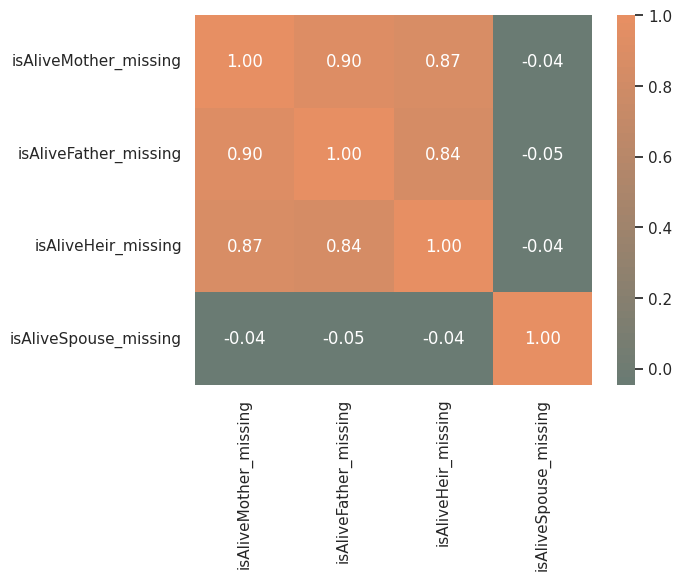

In [307]:
missings_indicators = ['isAliveMother_missing', 'isAliveFather_missing', 'isAliveHeir_missing', 'isAliveSpouse_missing']

corr_matrix = df[missings_indicators].corr()
sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f")

* Действительно видим высокую корреляцию между пропусками в данных признаках. Поэтому простой вариант с дополнительными столбцами-индикаторами нам не подходит.
* Далее проведем сравнение средних значений целевой переменной `isAlive` для разных категорий исследуемых признаков.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

1. **isAliveMother**

In [308]:
data.groupby('isAliveMother', dropna = False)['isAlive'].mean()

,isAlive
isAliveMother,
0.0,0.166667
1.0,0.166667
NaN,0.785575


- Здесь мы наблюдаем, что значение признака `isAliveMother` не влияет на значение целевой переменной, так как ее среднее значение (0.166667) одинаково для случаев `isAliveMother = 0` и `isAliveMother = 1`. А вот среднее значение на пропущенных данных гораздо выше.
- Поэтому заменим данны признак на новый `isMotherInfo`, который говорит о том есть ли информация о статусе матери (1) или нет (0).

```python
data['isMotherInfo'] = data['isAliveMother'].notna().astype(int)
```

2. **isAliveFather**

In [309]:
data.groupby('isAliveFather', dropna = False)['isAlive'].mean()

,isAlive
isAliveFather,
0.0,0.235294
1.0,0.400000
NaN,0.785668


* Видим, что каждая категория по-разному влияет на значение целевой переменной, поэтоу заменим данный признак тремя новыми: `father_dead`, `father_alive` и `father_status_unknown`:

```python
data['father_dead'] = (data['isAliveFather'] == 0).astype(int)
data['father_alive'] = (data['isAliveFather'] == 1).astype(int)  
data['father_status_unknown'] = data['isAliveFather'].isnull().astype(int)
```

3. **isAliveHeir**

In [310]:
data.groupby('isAliveHeir', dropna = False)['isAlive'].mean()

,isAlive
isAliveHeir,
0.0,0.000000
1.0,0.357143
NaN,0.785807


* Ситуация аналогична предыдущему пункту, но здесь мы видим еще больший перекос в плане средних значений. Также заменим данный признак тремя новыми: `heir_dead`, `heir_alive`, `heir_status_unknown`. Вполне может оказаться, что признак `heir_dead` станет хорошим предикатором смерти персонажа.

```python
data['heir_dead'] = (data['isAliveHeir'] == 0).astype(int)
data['heir_alive'] = (data['isAliveHeir'] == 1).astype(int)
data['heir_status_unknown'] = data['isAliveHeir'].isnull().astype(int)
```

4. **isAliveSpouse**

In [311]:
data.groupby('isAliveSpouse', dropna = False)['isAlive'].mean()

,isAlive
isAliveSpouse,
0.0,0.619048
1.0,0.753165
NaN,0.786293


* Здесь видим уже иную картину зависимости целевой переменной от данного признака. Аналогично преобразуем его в три категории.

```python
data['spouse_dead'] = (data['isAliveSpouse'] == 0).astype(int)
data['spouse_alive'] = (data['isAliveSpouse'] == 1).astype(int)
data['spouse_status_unknown'] = data['isAliveSpouse'].isnull().astype(int)
```

* Обернем этап преобразования бинарных признаков с пропусками в отдельную функцию.

In [312]:
def binary_missings_process(df):
  df['isMotherInfo'] = df['isAliveMother'].notna().astype(int)
  df.drop('isAliveMother', axis=1, inplace=True)

  df['father_dead'] = (df['isAliveFather'] == 0).astype(int)
  df['father_alive'] = (df['isAliveFather'] == 1).astype(int)
  df['father_status_unknown'] = df['isAliveFather'].isnull().astype(int)
  df.drop('isAliveFather', axis=1, inplace=True)

  df['heir_dead'] = (df['isAliveHeir'] == 0).astype(int)
  df['heir_alive'] = (df['isAliveHeir'] == 1).astype(int)
  df['heir_status_unknown'] = df['isAliveHeir'].isnull().astype(int)
  df.drop('isAliveHeir', axis=1, inplace=True)

  df['spouse_dead'] = (df['isAliveSpouse'] == 0).astype(int)
  df['spouse_alive'] = (df['isAliveSpouse'] == 1).astype(int)
  df['spouse_status_unknown'] = df['isAliveSpouse'].isnull().astype(int)
  df.drop('isAliveSpouse', axis=1, inplace=True)

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

1. Признаки `mother`, `father`, `heir`, `spouse` мы просто удалим. Они имеют те жи пропуски в большом количестве, что и рассматриваемые ранее признаки, но усложняют кодирование большим количеством уникальных значений. Более того, информация о родственниках мы уже фактически сохранили на предыдущих шагах в ходе преобразования признаков `isAliveMother`, `isAliveFather` и тд.

2. Признак `name` по сути дублирует идентификатор объекта, так как имеет уникальное значение для каждой записи (персонажа). Поэтому его мы также удаляем.

In [313]:
def drop_unnecessary(df):
  df.drop(['mother', 'father', 'heir', 'spouse', 'name'], axis=1, inplace=True)

3. Рассмотрим два оставшихся признака, имеющих пропуски: `title` и `house`. Основная сложность заключается в большом количестве уникальных значений. Также не забываем о тестовой выборке, которая может содержать значения данных признаков, не представленных в обучающей выборке. Сращивание всех уникальных признаков из двух выборок и поптыка их сгруппировать выглядит очень сложно и не гарантирует хорошего результата. Поэтому просто преобразуем данные признаки к индикаторам наличия: `has_title`, `has_house`.

In [314]:
for col in ['title', 'house']:
    print(f"\n{col.upper()}:")
    print(f"Уникальных значений: {data[col].nunique()}")
    print(f"Пропусков: {data[col].isna().sum()} ({data[col].isna().mean()*100:.1f}%)")
    print(f"Топ-5 значений:")
    print(data[col].value_counts().head())


TITLE:
Уникальных значений: 195
Пропусков: 840 (53.9%)
Топ-5 значений:
title
Ser            306
Maester         29
Archmaester     21
Lord            19
Septon          16
Name: count, dtype: int64

HOUSE:
Уникальных значений: 315
Пропусков: 381 (24.5%)
Топ-5 значений:
house
House Frey         89
Night's Watch      88
House Stark        56
House Targaryen    40
House Lannister    36
Name: count, dtype: int64


In [315]:
def create_house_title_indicators(df):
  df['has_title'] = df['title'].notna().astype(int)
  df['has_house'] = df['house'].notna().astype(int)
  df.drop(['title', 'house'], axis=1, inplace=True)

4. Соберем все предыдущие преобразования в одну функцию

In [316]:
def clean(df):
  scale_popularity(df)
  create_boolDeadRelations(df)
  create_age_features(df)
  create_dateOfBirth_value(df)
  create_culture_groups(df)
  binary_missings_process(df)
  drop_unnecessary(df)
  create_house_title_indicators(df)
  return df

5. Применим все обсуждаемые ранее преобразования, убедимся что пропусков не осталось и начнем разбираться с категориальными признаками.

In [317]:
data = clean(data)
print(f'Остались ли пропуски: {data.isna().any().any()}')

Остались ли пропуски: False


In [318]:
data.describe(include='object').T

,count,unique,top,freq
culture_grouped,1557,12,culture_no_data,1069


6. Остался один категориальный признак - `culture_grouped`. Воспользуемся методом **One Hot Encoding** и напишем две функции - одну для обучающей выборки, а вторую для тестовой, чтобы не переобучать кодировщик на тестовых данных.

In [319]:
# Кодировщик для обучающей выборки
def encode_train(df):
  encoder = OneHotEncoder(sparse_output=False)
  one_hot_encoded = encoder.fit_transform(df[['culture_grouped']])

  one_hot_df = pd.DataFrame(
      one_hot_encoded,
      columns=encoder.get_feature_names_out(['culture_grouped']),
      index=df.index
  )

  df_encoded = pd.concat([df, one_hot_df], axis=1)
  df_encoded = df_encoded.drop('culture_grouped', axis=1)

  return df_encoded, encoder

# Кодировщик для тестовой выборки
def encode_test(df, encoder):
  one_hot_encoded = encoder.transform(df[['culture_grouped']])

  one_hot_df = pd.DataFrame(
      one_hot_encoded,
      columns=encoder.get_feature_names_out(['culture_grouped']),
      index=df.index
  )

  df_encoded = pd.concat([df, one_hot_df], axis=1)
  df_encoded = df_encoded.drop('culture_grouped', axis=1)

  return df_encoded

In [320]:
data, _ = encode_train(data)

7. Проанализируем количественные признаки, построив тепловую карту матрицы корреляций. Видим, что выделенные числовые признаки нескоррелированы или слабо скореллированы между собой. Отметим только два момента:
- Между признаками `age_value` и `dateOfBirth_value` прослеживается положительная заметная корреляция, что обсуждалось еще на этапе создания данных признаков. Посмотрим как это повлияет на результат.
- Закодированные ранее признаки, связанные со статусами родственников, я сюда включать не стал, так как они по сути являются категориальными.

Text(0.5, 1.0, 'Корреляции числовых признаков')

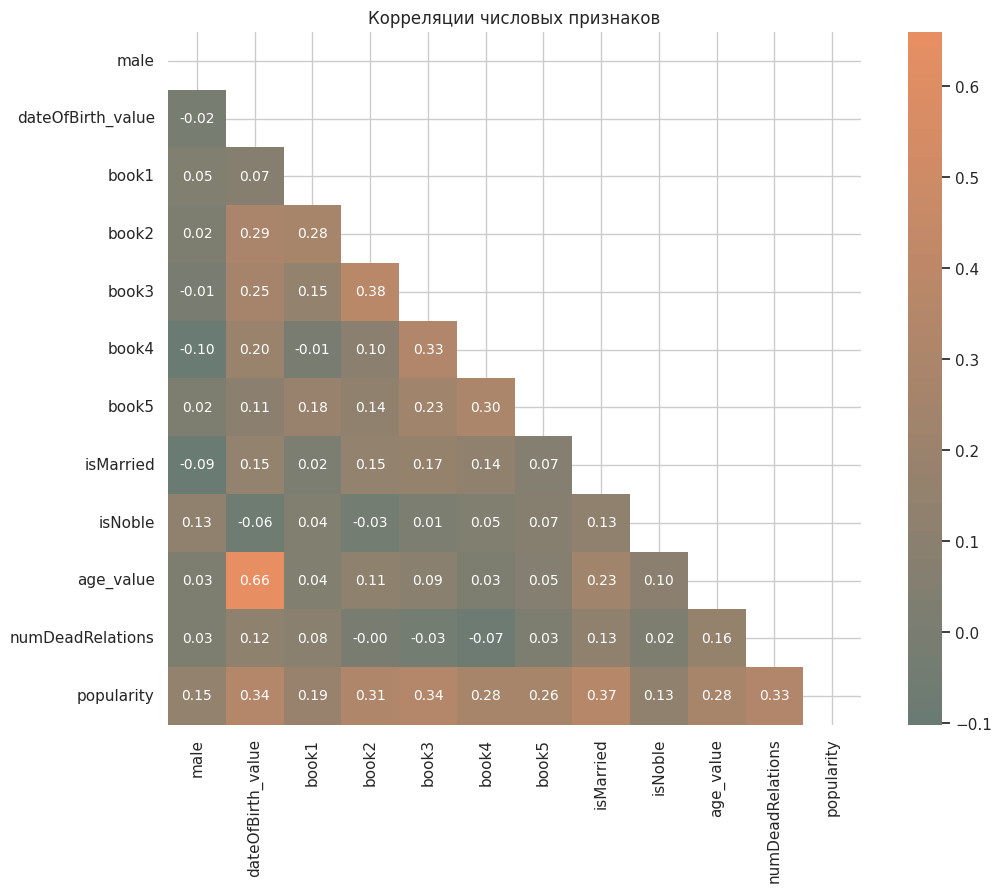

In [321]:
numerical_features = ['male', 'dateOfBirth_value', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'age_value', 'numDeadRelations', 'popularity']

corr_matrix = data[numerical_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix,
            mask=mask,
            cmap=cmap,
            square=True,
            cbar=True,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 10})
plt.title('Корреляции числовых признаков')

8. Вспомним, что значения всех признаков, полученных в ходе преобразований, находятся в пределах от 0.0 до 1.0, кроме `dateOfBirth_value` и `age_value`. Для данных признаков проведем масштабирование.

In [322]:
def scale_train(df, num_features=['dateOfBirth_value', 'age_value']):
  scaler = StandardScaler()
  scaled_values = scaler.fit_transform(df[num_features])
  df[num_features] = scaled_values
  return df, scaler

def scale_test(df, scaler, num_features=['dateOfBirth_value', 'age_value']):
    scaled_values = scaler.transform(df[num_features])
    df[num_features] = scaled_values
    return df

In [323]:
data, _ = scale_train(data)

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

* Для анализа взаимосвязи признаков и целевой переменной я выбрал метрику **Mutual Information (MI)**.

>**MI** - мера того, насколько знание одной величины уменьшает неопределенность (энтропией) другой. Ее преимущество перед корреляцией состоит в том, что она способна выявлять не только линейные зависимости. Однако, признак может быть не столь информативным сам по себе, но очень информативным в совокупности с другими признаками.

* Вцелом можно здесь попробовать различные инструменты типа `SequentialFeatureSelector`, `SelectFromModel` и другие классы из модуля feature_selection sklearn как предлагали в семинаре.

In [324]:
def make_mi_scores(df):
  X = df.copy()
  y = X.pop('isAlive')
  discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]

  mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
  mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
  mi_scores = mi_scores.sort_values(ascending=False)

  return mi_scores

In [325]:
def plot_mi_scores(scores):
  scores = scores.sort_values(ascending=True)
  width = np.arange(len(scores))
  ticks = list(scores.index)
  plt.figure(figsize=(15,10))
  plt.barh(width, scores)
  plt.yticks(width, ticks)
  plt.title("Mutual Information Scores")

* Постоим рейтинг значений **MI**. (Оставшиеся признаки имеют **MI = 0**, поэтому их я отмел).

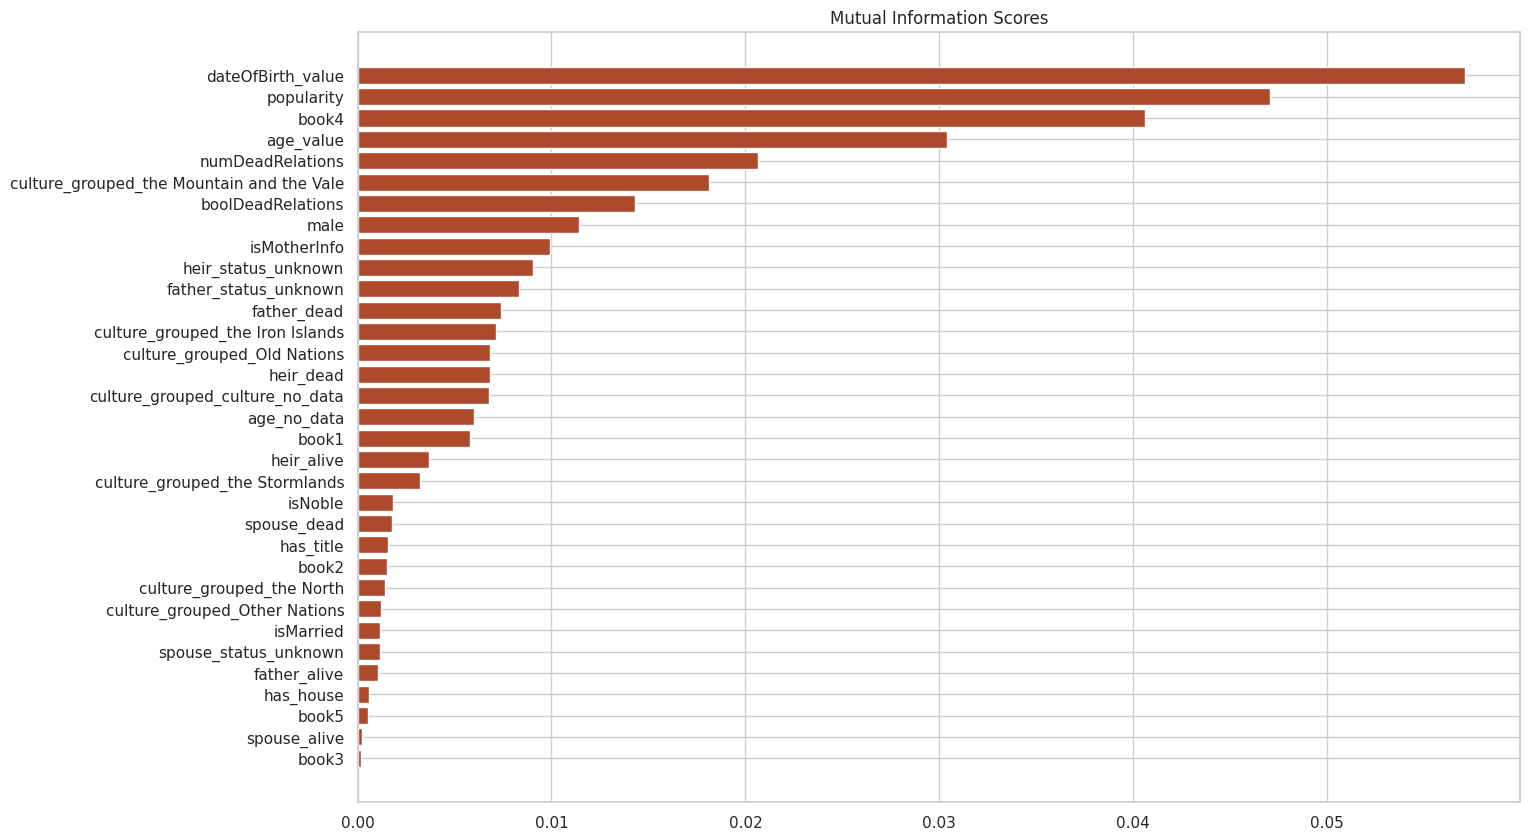

In [326]:
scores = make_mi_scores(data)
scores = scores[scores > 0]
plot_mi_scores(scores)

* Выделим указанные признаки в переменную `features` для дальнейшего обучения только на этих признаках. (Пробовал обучать на всем датасете и не увидел существенной разницы)

In [327]:
features = scores.index
features

Index(['dateOfBirth_value', 'popularity', 'book4', 'age_value',
       'numDeadRelations', 'culture_grouped_the Mountain and the Vale',
       'boolDeadRelations', 'male', 'isMotherInfo', 'heir_status_unknown',
       'father_status_unknown', 'father_dead',
       'culture_grouped_the Iron Islands', 'culture_grouped_Old Nations',
       'heir_dead', 'culture_grouped_culture_no_data', 'age_no_data', 'book1',
       'heir_alive', 'culture_grouped_the Stormlands', 'isNoble',
       'spouse_dead', 'has_title', 'book2', 'culture_grouped_the North',
       'culture_grouped_Other Nations', 'spouse_status_unknown', 'isMarried',
       'father_alive', 'has_house', 'book5', 'spouse_alive', 'book3'],
      dtype='object')

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [328]:
X = data[features]
y = data['isAlive']

**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [329]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

* Здесь я использую кросс-валидацию с количеством фолдов = 5. `GridSearchCV` производит поиск по сетке `param_grid` для выявления наилучших параметров из указанных. В данном случае я выбирал лучшую степень регуляризации (`C`) и алгоритм оптимизации (`solver`).

In [330]:
param_grid = {
    'C' : [100, 10, 1, 0.1, 0.01, 0.001],
    'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

clf = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

clf.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1, 0.1, 0.01, 0.001],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy', verbose=1)

* Для наглядности построим тепловую карту, которая отражает какие средние значения качества (`accuracy`) получались для различных комбинаций параметров сетки.

In [331]:
regularization = clf.cv_results_['param_C'].data
solvers = clf.cv_results_['param_solver'].data
accuracy = clf.cv_results_['mean_test_score']

Text(0.5, 1.0, 'Accuracy for LogRegression')

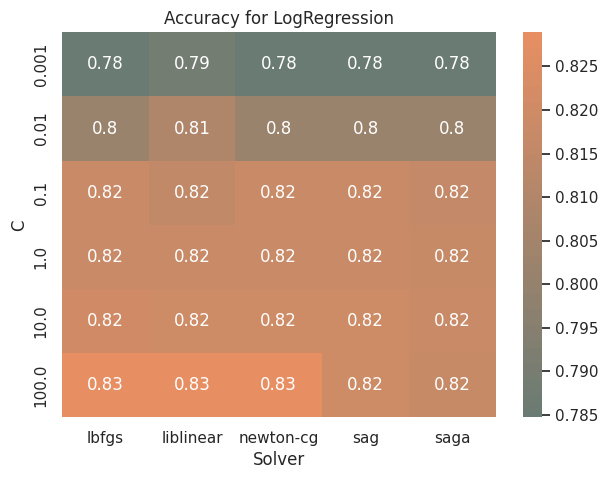

In [332]:
plt.figure(figsize=(7, 5))

heatmap_data = pd.DataFrame(data={'C': regularization, 'Solver': solvers, 'Accuracy': accuracy})
heatmap_data = heatmap_data.pivot(index='C', columns='Solver', values='Accuracy')

sns.heatmap(heatmap_data, annot=True, cmap=cmap).set_title('Accuracy for LogRegression')

* Выделим наилучшие параметры для создания итоговой модели.

In [333]:
best_C = clf.best_params_['C']
best_solver = clf.best_params_['solver']
best_score = clf.best_score_

print('Optimal Inverse of regularization strength ', best_C)
print('Optimal Algorithm                          ', best_solver)
print('Accuracy                                   ', best_score)

Optimal Inverse of regularization strength  100
Optimal Algorithm                           newton-cg
Accuracy                                    0.8289156626506025


* Строим модель на основе этих параметров.

In [334]:
model = LogisticRegression(C=best_C, solver=best_solver)
model.fit(X_train, y_train)

LogisticRegression(C=100, solver='newton-cg')

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [335]:
# Шаг 3. Предсказание на тестовых данных
predictions = model.predict(X_val)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_val, predictions)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8173


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

* Добавляем вспомогательную функцию для поправки данных в тестовом датасете

In [336]:
def fix_test_data(df):
  df.loc[1685, 'dateOfBirth'] = 278.0
  df.loc[1685, 'age'] = 0.0
  df.loc[1869, 'dateOfBirth'] = 299.0
  df.loc[1869, 'age'] = 0.0
  return df

* Объединяем все созданные ранее функции, чтобы одновременно обработать обучающую и тестовую выборки

In [337]:
def load_data():
  # Загружаем данные
  df_train = pd.read_csv("/content/game_of_thrones_train.csv", index_col='S.No')
  df_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col='S.No')

  # Исправляем ошибки в тестовых данных
  df_test = fix_test_data(df_test)

  # Очищаем, преобразуем и заполняем данные
  df_train = clean(df_train)
  df_test = clean(df_test)

  # Кодируем категориальные признаки
  df_train, encoder = encode_train(df_train)
  df_test = encode_test(df_test, encoder)

  # Масштабируем числовые признаки
  df_train, scaler = scale_train(df_train)
  df_test = scale_test(df_test, scaler)

  return df_train, df_test

* Загружаем данные

In [338]:
df_train, df_test = load_data()

X_train, y_train = df_train[features], df_train['isAlive']
X_test = df_test[features]

* Обучаем модель

In [339]:
model = LogisticRegression(C=best_C, solver=best_solver)
model.fit(X_train, y_train)

LogisticRegression(C=100, solver='newton-cg')

* Строим предсказания для тестового датасета

In [340]:
predictions = model.predict(X_test)

**Итоговый accuracy** = 0.7532133676092545

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [155]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 9.55MB/s]


In [156]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [157]:
submission['isAlive'] = predictions

Как сохранить измененный Pandas DataFrame в csv файл:

In [159]:
submission.to_csv("/content/new_submission.csv", index=False)